# Le apretaron la tibia y el cerebro se recuperó

**8,46 segundos.** Eso tarda en bajar de un poste un ratón al que le provocaron un daño
cerebral, una semana después del golpe.

Si mientras se recupera le comprimen la tibia una vez al día: **5,46 segundos**. Un ratón
sano tarda 5,62.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Cai et al. (2026), *Nature Neuroscience* — «Tibial bone compression promotes
recovery after brain injury through osteocyte PIEZO1»
**DOI:** [10.1038/s41593-026-02422-w](https://doi.org/10.1038/s41593-026-02422-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-22-compresion-tibia-cerebro/notebook.ipynb)

**Video:** [Pendiente]

## De qué va esto

Ya se sabía algo raro: tras un golpe fuerte en la cabeza, los huesos sanan más rápido y a
veces crecen donde no deberían. El cerebro lesionado le manda señales al hueso. La pregunta
que se hicieron Cai y su equipo es la contraria: **¿el hueso puede devolverle el favor?**

Para averiguarlo comprimieron la tibia de ratones con daño cerebral —una carga mecánica
suave y rítmica, sin cirugía ni fármacos— y midieron cómo se recuperaban. Después repitieron
el experimento en cerdos, quitaron el sensor mecánico del hueso para ver si el efecto
desaparecía, y transfirieron suero de un ratón a otro para ver si la señal viajaba por la
sangre.

Todos los datos de este notebook salen del *Source Data* del propio paper, hoja por hoja y
panel por panel. **Ojo con el alcance:** todo lo que viene son ratones y cerdos. Nada de
esto se ha probado en personas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MOMENTO = '1 semana'          # '1 semana' o '8 semanas' (Figs. 1c-1g)
COLOR_SANO = '#059669'        # SHAM — control sin golpe
COLOR_DANO = '#DC2626'        # TBI — daño cerebral, sin carga
COLOR_CARGA = '#2563EB'       # TBI+LOAD — daño cerebral + compresión tibial
COLOR_GRIS = '#BBBBBB'
COLOR_NEUTRO = '#6B7280'      # control sin tratamiento (PBS) — gris legible
FUENTE = ('Fuente: Cai et al. (2026), Nature Neuroscience | '
          'Datos: Source Data del propio paper (MOESM8)')

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM (local → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga de los 6 CSV extraídos del Source Data ──────────────
D = 'datos/'
pole = pd.read_csv(D + 'pole_test_raton.csv')        # Fig. 1c/1d — prueba del poste
mwm = pd.read_csv(D + 'mwm_raton.csv')               # Fig. 1f/1g — laberinto acuático
hist = pd.read_csv(D + 'histologia_hipocampo.csv')   # Fig. 2c/2d — tejido del hipocampo
ko = pd.read_csv(D + 'piezo1_ko.csv')                # Fig. 3d-3h — ratones sin Piezo1
suero = pd.read_csv(D + 'suero_transferencia.csv')   # Fig. 4b-4f — suero transferido
cerdos = pd.read_csv(D + 'cerdos_tmaze.csv')         # Fig. 7c/7d — laberinto en T


# ── Utilidades ────────────────────────────────────────────────
def esp(x, dec=2):
    """Formato español: coma decimal."""
    return f'{x:.{dec}f}'.replace('.', ',')


def cohen_d(a, b):
    """d de Cohen para grupos INDEPENDIENTES (SD combinada).

    El paper asigna animales distintos a cada grupo, así que no hay
    pareo posible: ni d pareado ni Wilcoxon aplican aquí.
    """
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2)
                 / (na + nb - 2))
    return abs(a.mean() - b.mean()) / sp


def compara(a, b):
    """Devuelve (d de Cohen, p de Mann-Whitney U de dos colas)."""
    return cohen_d(a, b), stats.mannwhitneyu(a, b, alternative='two-sided').pvalue


def fmt_p(p):
    """Notación científica para p muy pequeñas: '0,0000' se leería como cero."""
    return f'{p:.1e}' if p < 0.001 else esp(p, 4)


def serie(df, **filtros):
    """Filtra el dataframe por columna=valor y devuelve la columna 'valor'."""
    m = pd.Series(True, index=df.index)
    for col, val in filtros.items():
        m &= (df[col] == val)
    return df.loc[m, 'valor']


# ── Resumen de lo que acabamos de cargar ──────────────────────
print('Prueba del poste (Fig. 1d) — tiempo total, a', MOMENTO)
for g in ['SHAM', 'TBI', 'TBI+LOAD']:
    v = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo=g)
    print(f'  {g:9s} n={len(v):3d}  media={esp(v.mean())} s  '
          f'mediana={esp(v.median(), 1)} s  rango={esp(v.min(), 0)}–{esp(v.max(), 0)} s')

print('\nLaberinto acuático (Fig. 1g) — tiempo en el cuadrante diana, a', MOMENTO)
for g in ['SHAM', 'TBI', 'TBI+LOAD']:
    v = serie(mwm, metrica='tiempo_cuadrante_diana', momento=MOMENTO, grupo=g)
    print(f'  {g:9s} n={len(v):3d}  media={esp(v.mean())} s  sd={esp(v.std(ddof=1))}')

print('\nHipocampo (Fig. 2c/2d) — cuantificación en unidad no declarada por el paper')
for met, etiq in [('map2_hipocampo', 'MAP2'), ('celulas_nissl_positivas', 'Nissl+')]:
    fila = [f'{g} {esp(serie(hist, metrica=met, grupo=g).mean())}'
            for g in ['SHAM', 'TBI', 'TBI+LOAD']]
    print(f'  {etiq:7s} ' + '  |  '.join(fila))

print('\nn por grupo en el resto de experimentos')
print('  Piezo1 (Fig. 3e):',
      {g: int(len(serie(ko, metrica='tiempo_total', grupo=g))) for g in ko.grupo.unique()})
print('  Suero  (Fig. 4c):',
      {g: int(len(serie(suero, metrica='tiempo_total', grupo=g))) for g in suero.grupo.unique()})
print('  Cerdos (Fig. 7d, 1 semana):',
      {g: int(len(serie(cerdos, metrica='ensayo_reversal', momento='1 semana', grupo=g)))
       for g in ['SHAM', 'TBI', 'TBI+LOAD']})

Prueba del poste (Fig. 1d) — tiempo total, a 1 semana
  SHAM      n= 24  media=5,62 s  mediana=6,0 s  rango=4–7 s
  TBI       n= 24  media=8,46 s  mediana=8,0 s  rango=6–14 s
  TBI+LOAD  n= 24  media=5,46 s  mediana=6,0 s  rango=3–7 s

Laberinto acuático (Fig. 1g) — tiempo en el cuadrante diana, a 1 semana
  SHAM      n= 24  media=24,81 s  sd=8,46
  TBI       n= 24  media=14,39 s  sd=7,55
  TBI+LOAD  n= 24  media=23,34 s  sd=5,27

Hipocampo (Fig. 2c/2d) — cuantificación en unidad no declarada por el paper
  MAP2    SHAM 34,46  |  TBI 11,04  |  TBI+LOAD 32,27
  Nissl+  SHAM 85,54  |  TBI 51,62  |  TBI+LOAD 77,06

n por grupo en el resto de experimentos
  Piezo1 (Fig. 3e): {'Piezo1fl/fl TBI': 14, 'Piezo1fl/fl TBI+LOAD': 14, 'Piezo1-Sost-Cre TBI': 14, 'Piezo1-Sost-Cre TBI+LOAD': 17}
  Suero  (Fig. 4c): {'PBS': 14, 'suero TBI': 15, 'suero TBI+LOAD': 16}
  Cerdos (Fig. 7d, 1 semana): {'SHAM': 3, 'TBI': 6, 'TBI+LOAD': 6}


## Aquí está.

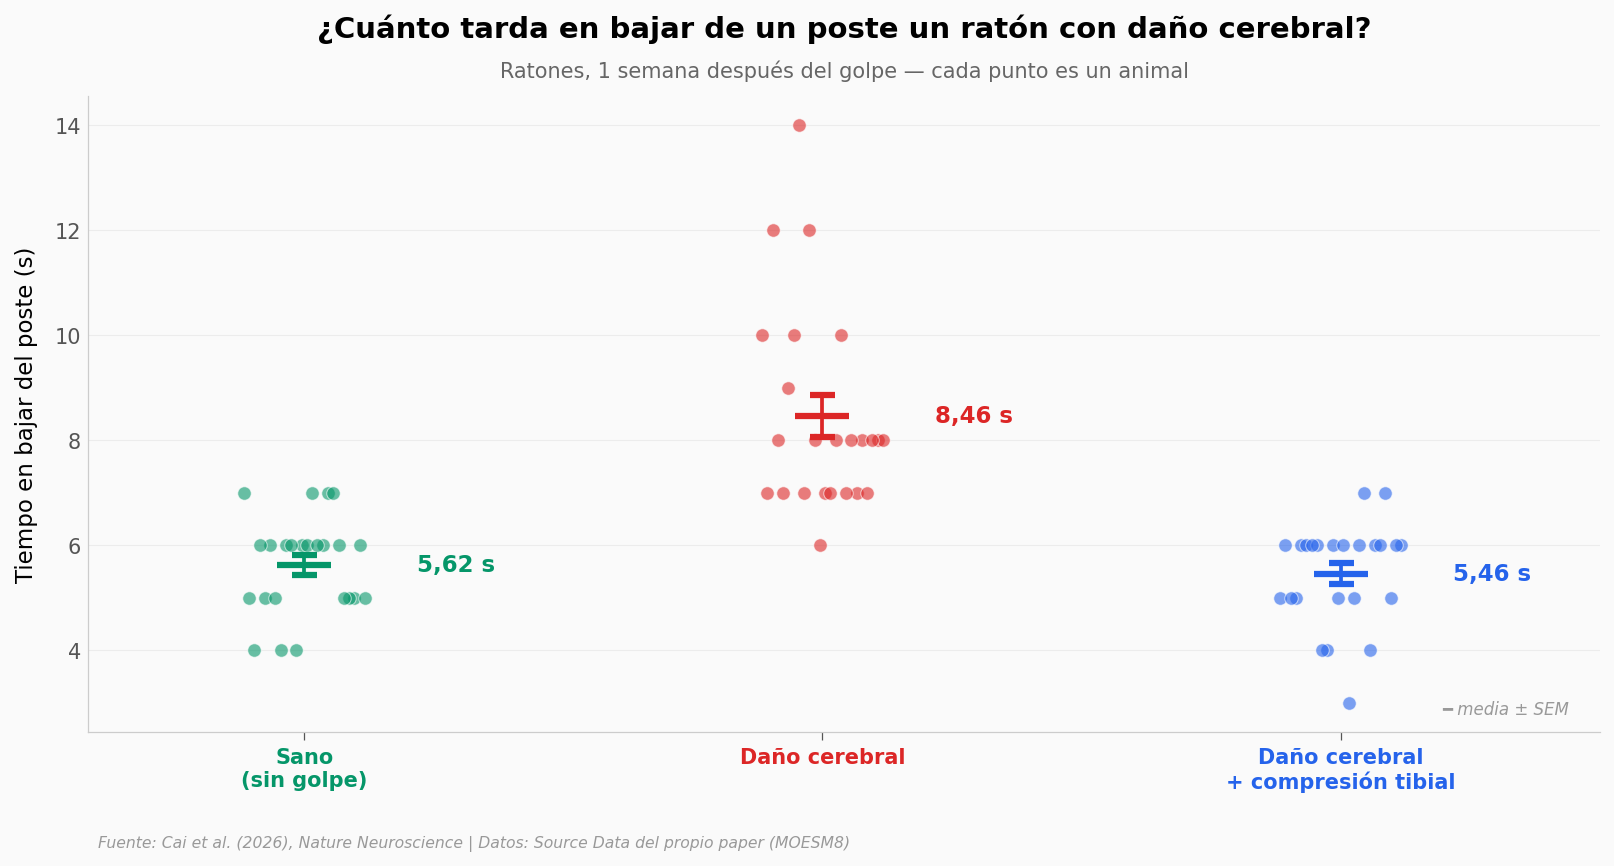

TBI → TBI+LOAD: -3,00 s (-35,5 %), d = 1,94, Mann-Whitney U p = 1.2e-08  (n = 24 vs 24)
SHAM → TBI     : d = 1,85, p = 3.6e-08  (el golpe sí dejó huella: ese es el efecto que hay que revertir)
Tiempo de giro : -0,75 s, d = 0,89, p = 0,0028


In [2]:
GRUPOS = [('SHAM', 'Sano\n(sin golpe)', COLOR_SANO),
          ('TBI', 'Daño cerebral', COLOR_DANO),
          ('TBI+LOAD', 'Daño cerebral\n+ compresión tibial', COLOR_CARGA)]

fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)
posiciones = [0, 1.2, 2.4]

for i, (clave, etiqueta, color) in enumerate(GRUPOS):
    v = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo=clave)
    n = len(v)
    x = np.linspace(posiciones[i] - 0.14, posiciones[i] + 0.14, n)
    np.random.shuffle(x)   # evita el artefacto de quedar ordenado por valor
    ax.scatter(x, v, color=color, s=42, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    sem = v.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones[i], v.mean(), yerr=sem, fmt='_', color=color,
                markersize=26, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(posiciones[i] + 0.26, v.mean(), f'{esp(v.mean())} s',
            fontsize=11, fontweight='bold', color=color, va='center')

ax.set_xticks(posiciones)
ax.set_xticklabels([g[1] for g in GRUPOS], fontsize=10, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), GRUPOS):
    tick.set_color(color)

ax.set_ylabel('Tiempo en bajar del poste (s)', fontsize=11)
ax.set_xlim(-0.5, 3.0)
ax.set_title('¿Cuánto tarda en bajar de un poste un ratón con daño cerebral?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Ratones, {MOMENTO} después del golpe — cada punto es un animal',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_poste.png', dpi=200, bbox_inches='tight')
plt.show()

tbi = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='TBI')
load = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='TBI+LOAD')
sham = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='SHAM')
d, p = compara(tbi, load)
print(f'TBI → TBI+LOAD: {esp(load.mean() - tbi.mean())} s '
      f'({esp(100 * (load.mean() - tbi.mean()) / tbi.mean(), 1)} %), '
      f'd = {esp(d)}, Mann-Whitney U p = {p:.1e}  (n = {len(tbi)} vs {len(load)})')
d2, p2 = compara(sham, tbi)
print(f'SHAM → TBI     : d = {esp(d2)}, p = {p2:.1e}  '
      f'(el golpe sí dejó huella: ese es el efecto que hay que revertir)')

giro_tbi = serie(pole, metrica='tiempo_giro', momento=MOMENTO, grupo='TBI')
giro_load = serie(pole, metrica='tiempo_giro', momento=MOMENTO, grupo='TBI+LOAD')
d3, p3 = compara(giro_tbi, giro_load)
print(f'Tiempo de giro : {esp(giro_load.mean() - giro_tbi.mean())} s, '
      f'd = {esp(d3)}, p = {fmt_p(p3)}')

Lo que llama la atención no es que la media baje: es **dónde acaba**.

El grupo con daño cerebral y compresión tibial termina en 5,46 s. El grupo sano, que nunca
recibió el golpe, está en 5,62 s. La diferencia entre ambos es más pequeña que la dispersión
dentro de cada uno: d = 0,18, sin significación (p = 0,66).

Y la distancia entre el grupo lesionado y el lesionado con carga es grande de verdad:
−3,00 s, una d de Cohen de 1,94. Por encima de 0,8 ya se considera un efecto grande; esto
casi lo duplica.

Un matiz que no conviene saltarse: el **tiempo de giro** —la parte de la prueba que mide
coordinación fina, no velocidad— también mejora, pero con una d de 0,89. Sigue siendo un
efecto grande, aunque menos de la mitad que el del tiempo total. No todo se recupera al
mismo ritmo.

## ¿Y la memoria?

Bajar de un poste es motor. Un golpe en la cabeza también se lleva por delante la memoria
espacial, y eso se mide de otra forma: el **laberinto acuático de Morris**. El ratón aprende
dónde hay una plataforma escondida bajo el agua; días después se le quita la plataforma y se
mira cuánto ronda el sitio donde estaba.

Dos números salen de ahí: cuántas veces cruza el punto exacto, y cuánto tiempo pasa en ese
cuarto de la piscina.

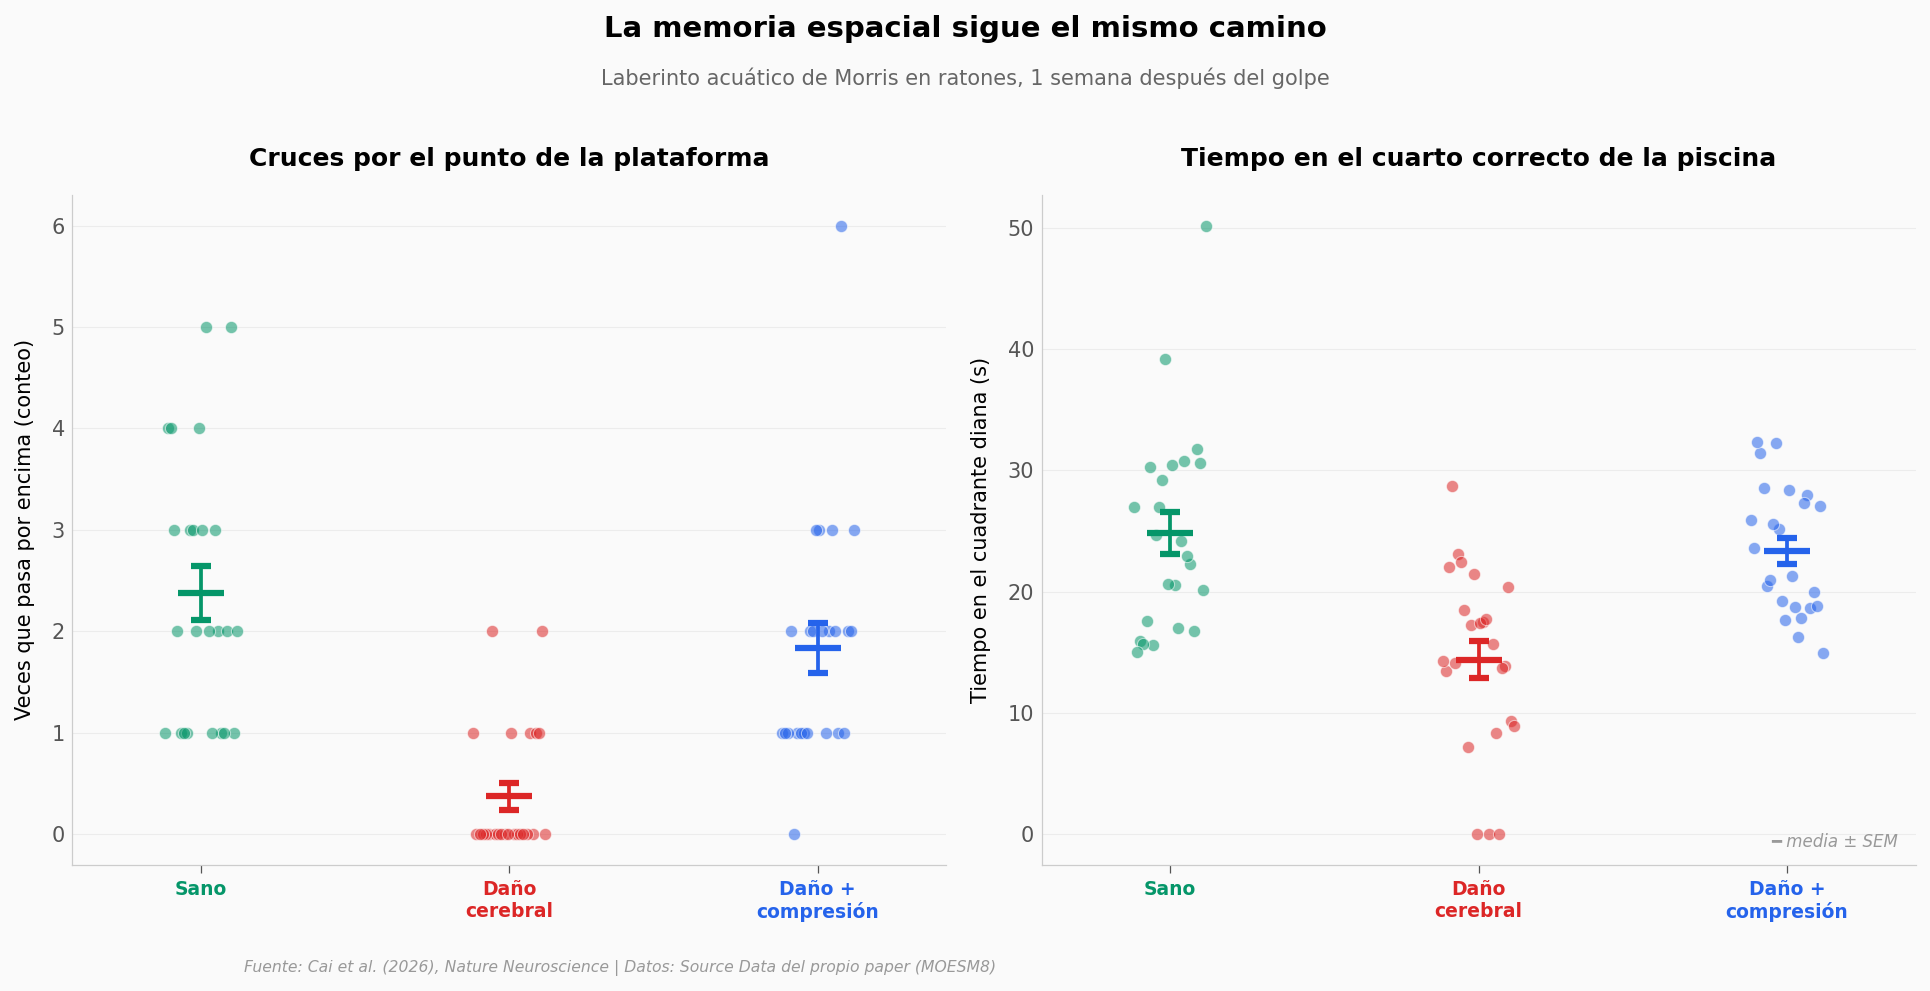

Cruces  : sano 2,38 | daño 0,38 | daño+compresión 1,83  →  d = 1,51, p = 2.1e-06
Cuadrante: sano 24,81 | daño 14,39 | daño+compresión 23,34  →  d = 1,38, p = 5.5e-05

En cruces damos valores absolutos, no porcentajes: con una media de 0,38 un cambio relativo no significa nada.
Cross-check cuadrante diana — nuestra diferencia de medias: 8,955 s | la que reporta el paper (Tukey): 8,953 s


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)
paneles = [('cruces_plataforma', 'Cruces por el punto de la plataforma',
            'Veces que pasa por encima (conteo)', axes[0]),
           ('tiempo_cuadrante_diana', 'Tiempo en el cuarto correcto de la piscina',
            'Tiempo en el cuadrante diana (s)', axes[1])]

for metrica, titulo, ylab, ax in paneles:
    for i, (clave, etiqueta, color) in enumerate(GRUPOS):
        v = serie(mwm, metrica=metrica, momento=MOMENTO, grupo=clave)
        n = len(v)
        x = np.linspace(posiciones[i] - 0.14, posiciones[i] + 0.14, n)
        np.random.shuffle(x)
        ax.scatter(x, v, color=color, s=34, alpha=0.55,
                   edgecolors='white', linewidths=0.5, zorder=5)
        sem = v.std(ddof=1) / np.sqrt(n)
        ax.errorbar(posiciones[i], v.mean(), yerr=sem, fmt='_', color=color,
                    markersize=22, markeredgewidth=3, capsize=5, capthick=1.5, zorder=6)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(['Sano', 'Daño\ncerebral', 'Daño +\ncompresión'],
                       fontsize=9, fontweight='bold')
    for tick, (_, _, color) in zip(ax.get_xticklabels(), GRUPOS):
        tick.set_color(color)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
    ax.set_xlim(-0.5, 2.9)

axes[1].text(0.98, 0.02, '━ media ± SEM', transform=axes[1].transAxes,
             fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
# tight_layout PRIMERO: recalcula el área de ejes y desplazaría el suptitle si
# se fijara antes (el subtítulo acabaría encima del título).
plt.tight_layout()
fig.suptitle('La memoria espacial sigue el mismo camino', fontsize=14,
             fontweight='bold', y=1.13)
fig.text(0.5, 1.045, f'Laberinto acuático de Morris en ratones, {MOMENTO} después del golpe',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/memoria_laberinto.png', dpi=200, bbox_inches='tight')
plt.show()

for metrica, etiqueta in [('cruces_plataforma', 'Cruces  '),
                          ('tiempo_cuadrante_diana', 'Cuadrante')]:
    a = serie(mwm, metrica=metrica, momento=MOMENTO, grupo='TBI')
    b = serie(mwm, metrica=metrica, momento=MOMENTO, grupo='TBI+LOAD')
    c = serie(mwm, metrica=metrica, momento=MOMENTO, grupo='SHAM')
    d, p = compara(a, b)
    print(f'{etiqueta}: sano {esp(c.mean())} | daño {esp(a.mean())} | '
          f'daño+compresión {esp(b.mean())}  →  d = {esp(d)}, p = {p:.1e}')

# Los cruces de plataforma promedian 0,38 en el grupo con daño: una escala así de
# pegada al cero convierte cualquier porcentaje en ruido (regla de escalas ratio).
print('\nEn cruces damos valores absolutos, no porcentajes: con una media de 0,38 '
      'un cambio relativo no significa nada.')

# Cross-check contra el reporte estadístico completo del paper (MOESM3, Tabla Suppl. 2)
a = serie(mwm, metrica='tiempo_cuadrante_diana', momento='1 semana', grupo='TBI')
b = serie(mwm, metrica='tiempo_cuadrante_diana', momento='1 semana', grupo='TBI+LOAD')
print(f'Cross-check cuadrante diana — nuestra diferencia de medias: '
      f'{esp(b.mean() - a.mean(), 3)} s | la que reporta el paper (Tukey): 8,953 s')

## ¿Por qué el hueso?

Hasta aquí tenemos un efecto grande y repetido en dos pruebas distintas. Falta lo importante:
**por qué**. Que dos cosas cambien a la vez no dice quién empuja a quién.

El equipo fue a buscar el interruptor. Dentro del hueso viven los **osteocitos**, unas células
atrapadas en la matriz ósea que notan cuándo el hueso se deforma. Su sensor se llama
**PIEZO1**: un canal que se abre físicamente cuando la célula se aplasta.

La prueba limpia es quitarlo. Si el beneficio depende de que el osteocito *sienta* la
compresión, un ratón sin Piezo1 en esas células debería quedarse sin beneficio — aunque le
comprimas la tibia exactamente igual.

Y hay una segunda pregunta, todavía más directa: si la señal viaja por la sangre, el suero de
un ratón comprimido debería funcionar en otro ratón que nunca pisó la máquina.

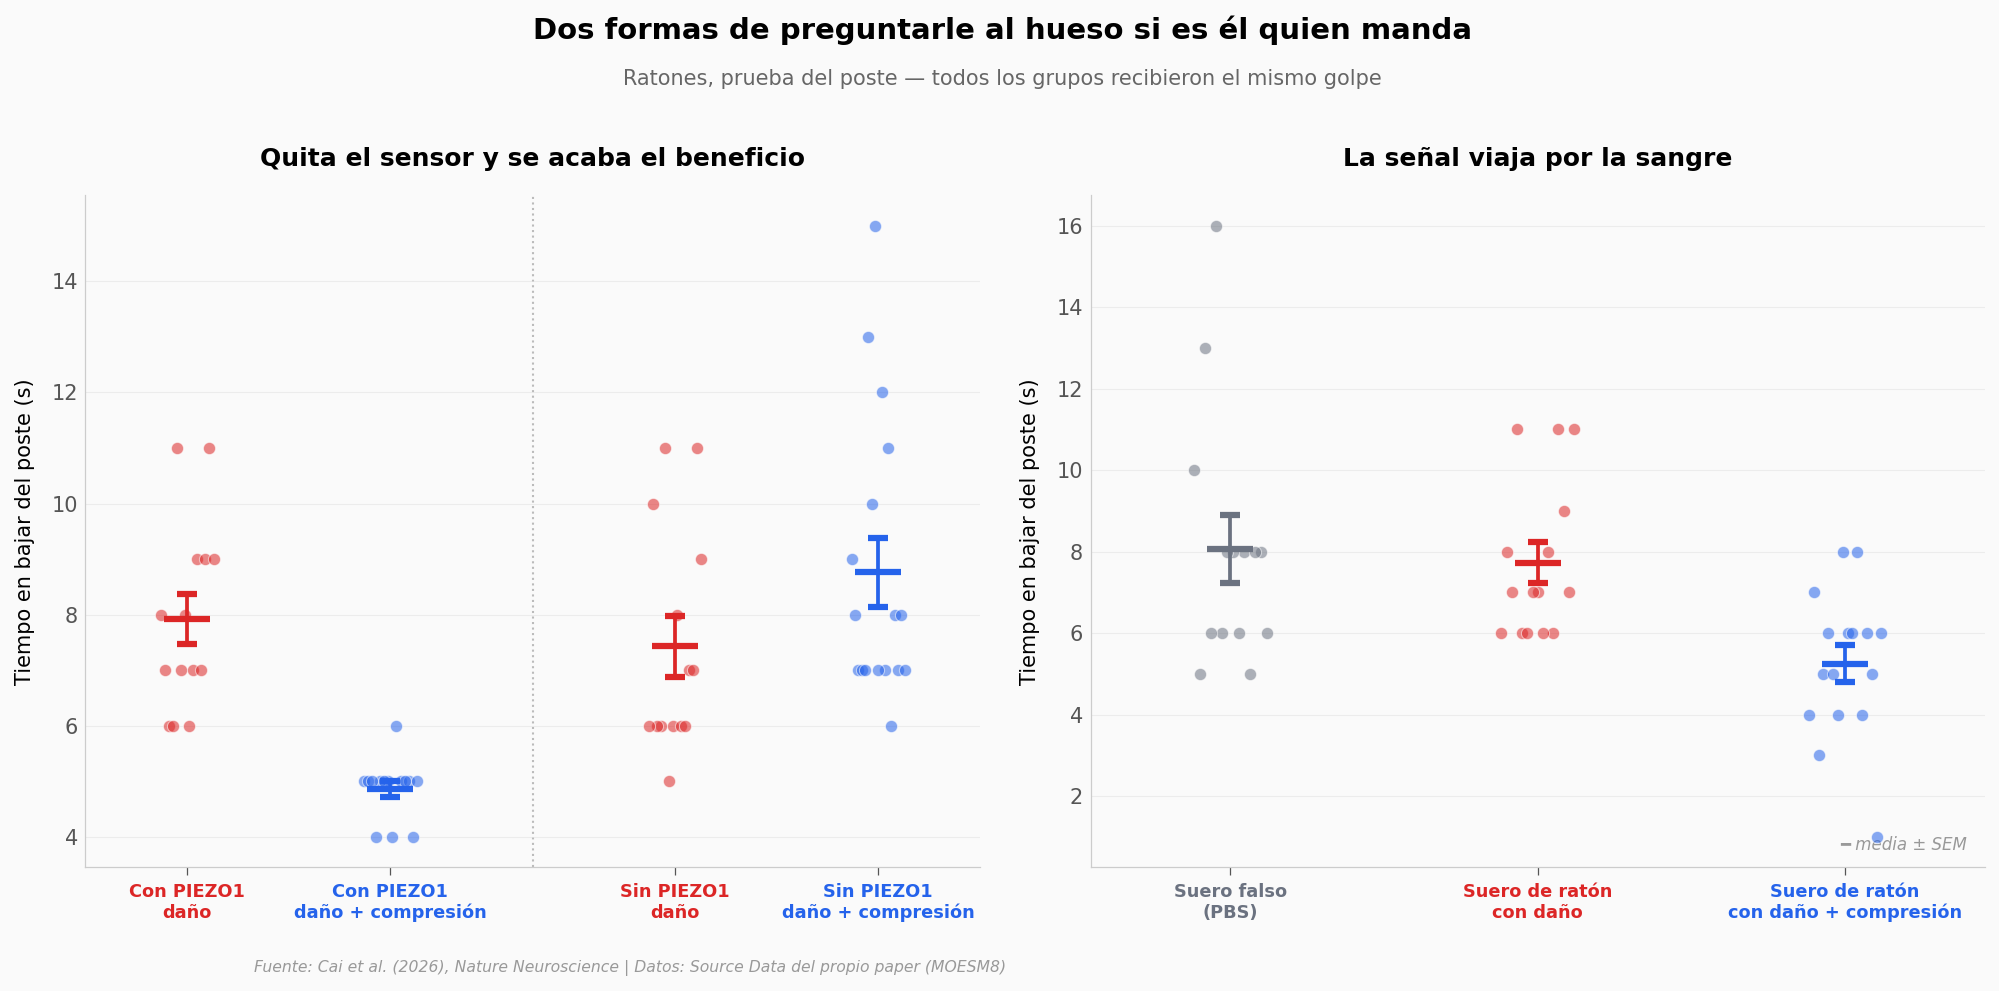

PIEZO1 — ¿la compresión sigue ayudando si el osteocito no la siente?
  Con PIEZO1: 7,93 s → 4,86 s  (d = 2,46, p = 5.8e-06, n = 14 vs 14)
  Sin PIEZO1: 7,43 s → 8,76 s  (d = 0,57, p = 0,0626, n = 14 vs 17)

  La misma comparación en los otros tres paneles de la Fig. 3:
    tiempo de giro        con PIEZO1 d = 1,84  |  sin PIEZO1 d = 0,26
    cruces de plataforma  con PIEZO1 d = 1,60  |  sin PIEZO1 d = 0,10
    cuadrante diana       con PIEZO1 d = 1,26  |  sin PIEZO1 d = 0,25

Suero transferido a ratones que nunca pisaron la máquina:
  suero de daño 7,73 s → suero de daño+compresión 5,25 s  (d = 1,34, p = 0,0012, n = 15 vs 16)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
np.random.seed(42)

# ── Panel izquierdo: quitar PIEZO1 de los osteocitos ──────────
ax = axes[0]
KO_GRUPOS = [('Piezo1fl/fl TBI', 'Con PIEZO1\ndaño', COLOR_DANO, 0),
             ('Piezo1fl/fl TBI+LOAD', 'Con PIEZO1\ndaño + compresión', COLOR_CARGA, 1.0),
             ('Piezo1-Sost-Cre TBI', 'Sin PIEZO1\ndaño', COLOR_DANO, 2.4),
             ('Piezo1-Sost-Cre TBI+LOAD', 'Sin PIEZO1\ndaño + compresión', COLOR_CARGA, 3.4)]

for clave, etiqueta, color, pos in KO_GRUPOS:
    v = serie(ko, metrica='tiempo_total', grupo=clave)
    n = len(v)
    x = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x)
    ax.scatter(x, v, color=color, s=34, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    sem = v.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, v.mean(), yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=5, capthick=1.5, zorder=6)

ax.set_xticks([p for _, _, _, p in KO_GRUPOS])
ax.set_xticklabels([e for _, e, _, _ in KO_GRUPOS], fontsize=8.5, fontweight='bold')
for tick, (_, _, color, _) in zip(ax.get_xticklabels(), KO_GRUPOS):
    tick.set_color(color)
ax.set_ylabel('Tiempo en bajar del poste (s)', fontsize=10)
ax.set_title('Quita el sensor y se acaba el beneficio', fontsize=12,
             fontweight='bold', pad=14)
ax.axvline(x=1.7, color=COLOR_GRIS, linewidth=1, linestyle=':', zorder=1)
ax.set_xlim(-0.5, 3.9)

# ── Panel derecho: transferir suero ───────────────────────────
ax = axes[1]
SUERO_GRUPOS = [('PBS', 'Suero falso\n(PBS)', COLOR_NEUTRO, 0),
                ('suero TBI', 'Suero de ratón\ncon daño', COLOR_DANO, 1.1),
                ('suero TBI+LOAD', 'Suero de ratón\ncon daño + compresión', COLOR_CARGA, 2.2)]

for clave, etiqueta, color, pos in SUERO_GRUPOS:
    v = serie(suero, metrica='tiempo_total', grupo=clave)
    n = len(v)
    x = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x)
    ax.scatter(x, v, color=color, s=34, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    sem = v.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, v.mean(), yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=5, capthick=1.5, zorder=6)

ax.set_xticks([p for _, _, _, p in SUERO_GRUPOS])
ax.set_xticklabels([e for _, e, _, _ in SUERO_GRUPOS], fontsize=8.5, fontweight='bold')
for tick, (_, _, color, _) in zip(ax.get_xticklabels(), SUERO_GRUPOS):
    tick.set_color(color)
ax.set_ylabel('Tiempo en bajar del poste (s)', fontsize=10)
ax.set_title('La señal viaja por la sangre', fontsize=12, fontweight='bold', pad=14)
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
ax.set_xlim(-0.5, 2.7)

plt.tight_layout()
fig.suptitle('Dos formas de preguntarle al hueso si es él quien manda',
             fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, 'Ratones, prueba del poste — todos los grupos recibieron el mismo golpe',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mecanismo_piezo1_suero.png', dpi=200, bbox_inches='tight')
plt.show()

print('PIEZO1 — ¿la compresión sigue ayudando si el osteocito no la siente?')
for etiqueta, a_key, b_key in [
        ('Con PIEZO1', 'Piezo1fl/fl TBI', 'Piezo1fl/fl TBI+LOAD'),
        ('Sin PIEZO1', 'Piezo1-Sost-Cre TBI', 'Piezo1-Sost-Cre TBI+LOAD')]:
    a = serie(ko, metrica='tiempo_total', grupo=a_key)
    b = serie(ko, metrica='tiempo_total', grupo=b_key)
    d, p = compara(a, b)
    print(f'  {etiqueta}: {esp(a.mean())} s → {esp(b.mean())} s  '
          f'(d = {esp(d)}, p = {fmt_p(p)}, n = {len(a)} vs {len(b)})')

print('\n  La misma comparación en los otros tres paneles de la Fig. 3:')
for metrica, etiqueta in [('tiempo_giro', 'tiempo de giro      '),
                          ('cruces_plataforma', 'cruces de plataforma'),
                          ('tiempo_cuadrante_diana', 'cuadrante diana     ')]:
    d_con, _ = compara(serie(ko, metrica=metrica, grupo='Piezo1fl/fl TBI'),
                       serie(ko, metrica=metrica, grupo='Piezo1fl/fl TBI+LOAD'))
    d_sin, _ = compara(serie(ko, metrica=metrica, grupo='Piezo1-Sost-Cre TBI'),
                       serie(ko, metrica=metrica, grupo='Piezo1-Sost-Cre TBI+LOAD'))
    print(f'    {etiqueta}  con PIEZO1 d = {esp(d_con)}  |  sin PIEZO1 d = {esp(d_sin)}')

print('\nSuero transferido a ratones que nunca pisaron la máquina:')
a = serie(suero, metrica='tiempo_total', grupo='suero TBI')
b = serie(suero, metrica='tiempo_total', grupo='suero TBI+LOAD')
d, p = compara(a, b)
print(f'  suero de daño {esp(a.mean())} s → suero de daño+compresión {esp(b.mean())} s  '
      f'(d = {esp(d)}, p = {fmt_p(p)}, n = {len(a)} vs {len(b)})')

## El salto a un animal grande

Un ratón pesa 25 gramos. Su tibia, su circulación y su cerebro tienen poco que ver con los
nuestros en tamaño, y el sitio donde muchos resultados de neurociencia se quedan atascados es
justo ese: funcionan en ratón y no escalan.

Por eso la parte de los cerdos es la que más pesa. Mismo protocolo —golpe, compresión de la
tibia— y una prueba de flexibilidad cognitiva: el **laberinto en T**. El animal aprende que la
comida está a un lado; luego se la cambian de sitio y hay que medir cuánto tarda en desaprender
la regla vieja. Eso es el *ensayo invertido*, y es la parte que peor lleva un cerebro dañado.

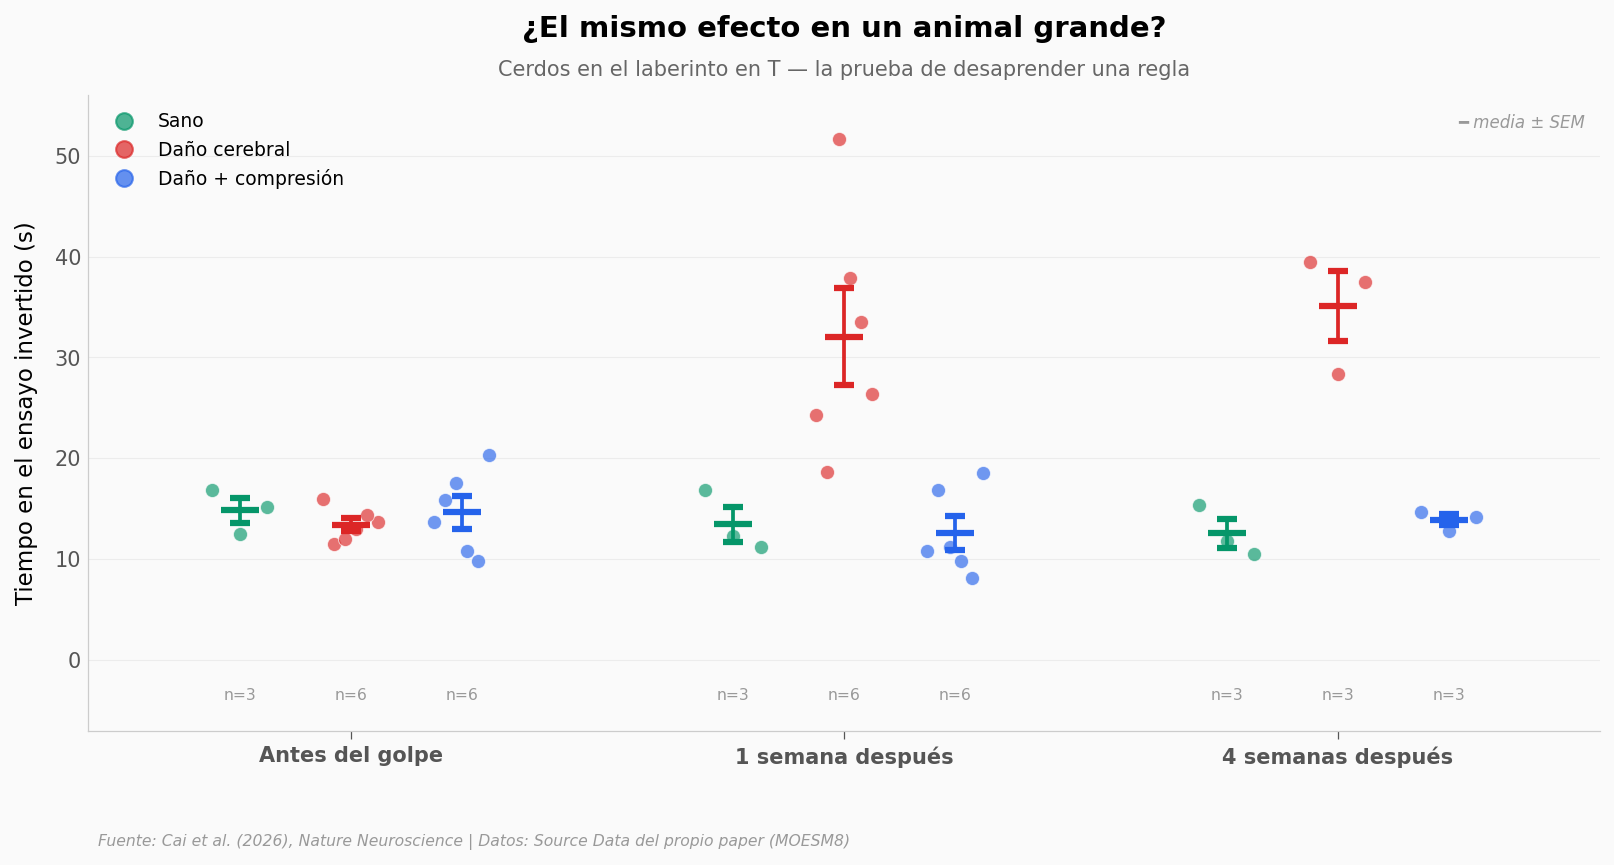

Antes del golpe   : daño 13,42 s | daño+compresión 14,67 s  →  d = 0,41, p = 0,7483  (n = 6 vs 6)
1 semana después  : daño 32,05 s | daño+compresión 12,55 s  →  d = 2,21, p = 0,0022  (n = 6 vs 6)
4 semanas después : daño 35,11 s | daño+compresión 13,89 s  →  d = 4,98, p = 0,1000  (n = 3 vs 3)

A 4 semanas hay 3 cerdos por grupo. Con esos números el Mann-Whitney no puede
bajar de p = 0,1 ni aunque los grupos no se solapen: es el suelo del test, no una
señal de que no haya efecto. Ahí hay que mirar la d y el n, no la p.


In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))
MOMENTOS = ['antes del TCE', '1 semana', '4 semanas']
ETIQ_MOMENTOS = ['Antes del golpe', '1 semana después', '4 semanas después']
np.random.seed(42)

bloques = [0, 1.6, 3.2]
offsets = {'SHAM': -0.36, 'TBI': 0.0, 'TBI+LOAD': 0.36}

for j, mom in enumerate(MOMENTOS):
    for clave, _, color in GRUPOS:
        v = serie(cerdos, metrica='ensayo_reversal', momento=mom, grupo=clave)
        n = len(v)
        pos = bloques[j] + offsets[clave]
        x = np.linspace(pos - 0.09, pos + 0.09, n)
        np.random.shuffle(x)
        ax.scatter(x, v, color=color, s=46, alpha=0.65,
                   edgecolors='white', linewidths=0.5, zorder=5)
        sem = v.std(ddof=1) / np.sqrt(n)
        ax.errorbar(pos, v.mean(), yerr=sem, fmt='_', color=color,
                    markersize=18, markeredgewidth=3, capsize=5, capthick=1.5, zorder=6)
        ax.text(pos, -4.0, f'n={n}', fontsize=7.5, color='#999999', ha='center')

# Con 3 grupos repetidos en 3 bloques temporales, las etiquetas inline chocan
# con los propios puntos (el grupo con daño llega a 51 s). Aquí la leyenda es
# la opción legible; va arriba a la izquierda, la zona vacía de la gráfica.
handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=color,
                      markersize=8, alpha=0.7,
                      label={'SHAM': 'Sano', 'TBI': 'Daño cerebral',
                             'TBI+LOAD': 'Daño + compresión'}[clave])
           for clave, _, color in GRUPOS]
ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.9)

ax.set_xticks(bloques)
ax.set_xticklabels(ETIQ_MOMENTOS, fontsize=10, fontweight='bold')
ax.set_ylabel('Tiempo en el ensayo invertido (s)', fontsize=11)
ax.set_ylim(-7, 56)
ax.set_xlim(-0.85, 4.05)
ax.set_title('¿El mismo efecto en un animal grande?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cerdos en el laberinto en T — la prueba de desaprender una regla',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.99, 0.97, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cerdos_laberinto_t.png', dpi=200, bbox_inches='tight')
plt.show()

for mom, etiq in zip(MOMENTOS, ETIQ_MOMENTOS):
    a = serie(cerdos, metrica='ensayo_reversal', momento=mom, grupo='TBI')
    b = serie(cerdos, metrica='ensayo_reversal', momento=mom, grupo='TBI+LOAD')
    d, p = compara(a, b)
    print(f'{etiq:18s}: daño {esp(a.mean())} s | daño+compresión {esp(b.mean())} s  →  '
          f'd = {esp(d)}, p = {esp(p, 4)}  (n = {len(a)} vs {len(b)})')

# A 4 semanas quedan 3 animales por grupo. Con n=3 vs 3, el menor valor que
# puede devolver un Mann-Whitney de dos colas es exactamente 0,1: el test se
# queda sin resolución antes de poder decir nada. El tamaño de efecto sí informa.
print('\nA 4 semanas hay 3 cerdos por grupo. Con esos números el Mann-Whitney no puede')
print('bajar de p = 0,1 ni aunque los grupos no se solapen: es el suelo del test, no una')
print('señal de que no haya efecto. Ahí hay que mirar la d y el n, no la p.')

## ¿Qué tan lejos llega el efecto?

Las medias cuentan una parte. Lo que no cuentan es qué pasó con los animales que peor lo
llevaron.

En la prueba del poste, los tiempos son segundos enteros. Eso permite ver la distribución
completa, animal por animal, en vez del resumen.

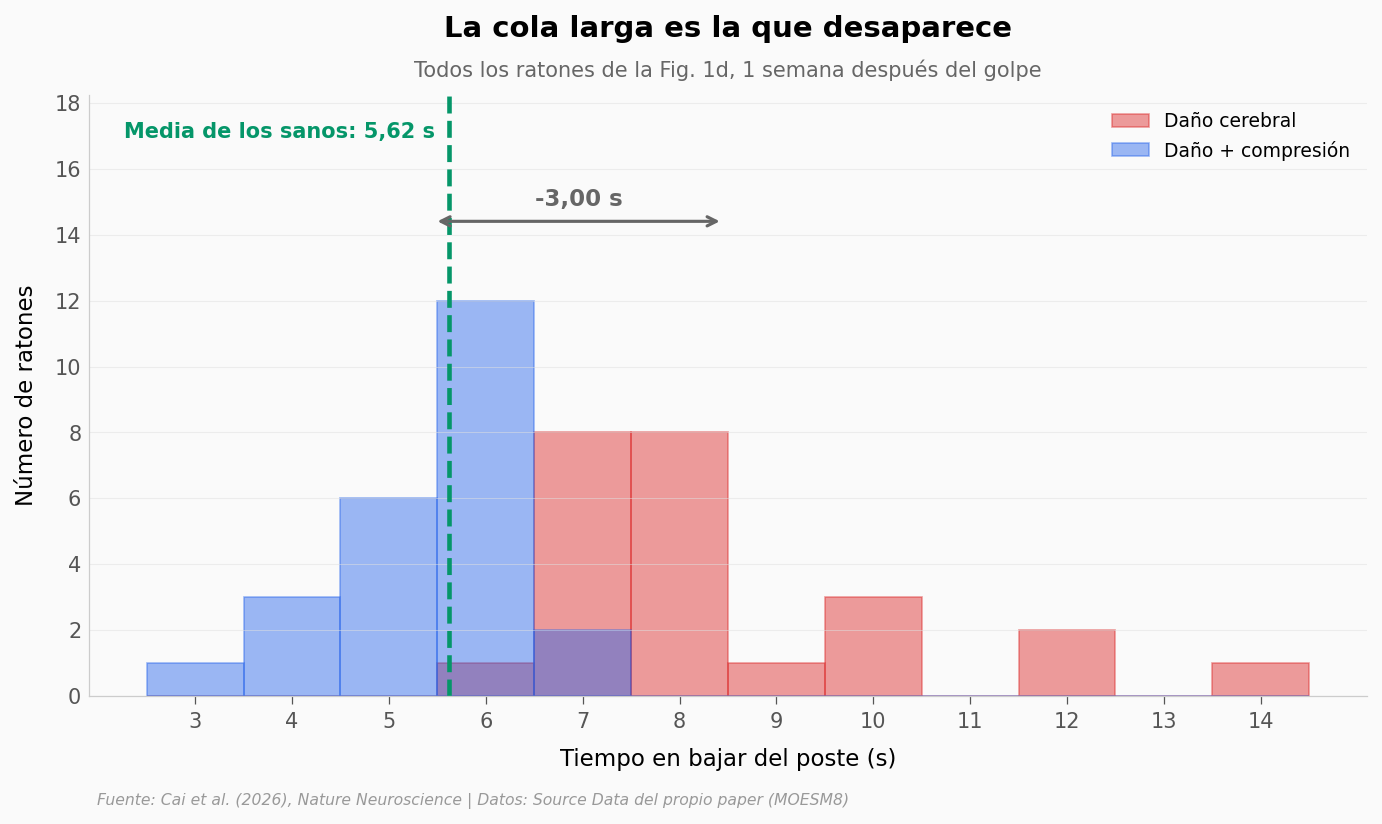

Daño cerebral       : rango 6–14 s, mediana 8,0 s, IQR 7,0–9,2 s  (n = 24)
Daño + compresión   : rango 3–7 s, mediana 6,0 s, IQR 5,0–6,0 s  (n = 24)
Sanos               : rango 4–7 s, mediana 6,0 s  (n = 24)

Ratones por encima de 9 s — daño cerebral: 6 de 24 | daño + compresión: 0 de 24


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))

tbi = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='TBI')
load = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='TBI+LOAD')
sham = serie(pole, metrica='tiempo_total', momento=MOMENTO, grupo='SHAM')

bins = np.arange(2.5, 15.5, 1.0)   # un bin por segundo entero
n1, _, _ = ax.hist(tbi, bins=bins, color=COLOR_DANO, alpha=0.45,
                   edgecolor=COLOR_DANO, linewidth=0.8, label='Daño cerebral')
n2, _, _ = ax.hist(load, bins=bins, color=COLOR_CARGA, alpha=0.45,
                   edgecolor=COLOR_CARGA, linewidth=0.8, label='Daño + compresión')

# Margen amplio arriba: la flecha y las etiquetas van POR ENCIMA de la barra
# más alta (12 ratones), no cruzándola.
y_max = max(n1.max(), n2.max()) * 1.52
ax.set_ylim(0, y_max)
ax.axvline(x=sham.mean(), color=COLOR_SANO, linewidth=2.2, linestyle='--')
ax.text(sham.mean() - 0.15, y_max * 0.955, f'Media de los sanos: {esp(sham.mean())} s',
        fontsize=10, fontweight='bold', color=COLOR_SANO, ha='right', va='top')

ax.annotate('', xy=(load.mean(), y_max * 0.79), xytext=(tbi.mean(), y_max * 0.79),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((load.mean() + tbi.mean()) / 2, y_max * 0.815,
        f'{esp(load.mean() - tbi.mean())} s', fontsize=11, fontweight='bold',
        color='#666666', ha='center')

ax.set_xlabel('Tiempo en bajar del poste (s)', fontsize=11)
ax.set_ylabel('Número de ratones', fontsize=11)
ax.set_xticks(np.arange(3, 15, 1))
ax.set_yticks(np.arange(0, int(y_max) + 1, 2))   # es un conteo: ticks enteros
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_title('La cola larga es la que desaparece', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Todos los ratones de la Fig. 1d, {MOMENTO} después del golpe',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_poste.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Daño cerebral       : rango {esp(tbi.min(), 0)}–{esp(tbi.max(), 0)} s, '
      f'mediana {esp(tbi.median(), 1)} s, IQR {esp(tbi.quantile(.25), 1)}–'
      f'{esp(tbi.quantile(.75), 1)} s  (n = {len(tbi)})')
print(f'Daño + compresión   : rango {esp(load.min(), 0)}–{esp(load.max(), 0)} s, '
      f'mediana {esp(load.median(), 1)} s, IQR {esp(load.quantile(.25), 1)}–'
      f'{esp(load.quantile(.75), 1)} s  (n = {len(load)})')
print(f'Sanos               : rango {esp(sham.min(), 0)}–{esp(sham.max(), 0)} s, '
      f'mediana {esp(sham.median(), 1)} s  (n = {len(sham)})')
print(f'\nRatones por encima de 9 s — daño cerebral: {int((tbi > 9).sum())} de {len(tbi)} | '
      f'daño + compresión: {int((load > 9).sum())} de {len(load)}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Comprimir la tibia acorta el tiempo de bajada del poste tras el daño cerebral | ✅ | 8,46 s → 5,46 s a 1 semana; d = 1,94; Mann-Whitney p = 1,2 × 10⁻⁸; n = 24 vs 24 |
| El grupo con compresión queda al nivel del grupo sano en esa prueba | ✅ | 5,46 s vs 5,62 s — d = 0,18 (n.s., p = 0,66); la diferencia es menor que la dispersión interna de cada grupo |
| La memoria espacial también mejora | ✅ | Cuadrante diana +8,96 s (d = 1,38; p = 5,5 × 10⁻⁵); cruces 0,38 → 1,83 (d = 1,51). Nuestra diferencia de medias en el cuadrante coincide con la que reporta el paper: 8,955 s frente a 8,953 s |
| El beneficio desaparece sin PIEZO1 en los osteocitos | ✅ | Con PIEZO1: d = 1,26–2,46 en los cuatro paneles de la Fig. 3. Sin PIEZO1: d = 0,10–0,57, ninguno con p < 0,05 |
| El suero de un ratón comprimido reproduce el efecto en otro ratón | ✅ | 7,73 s → 5,25 s (d = 1,34; p = 0,0012; n = 15 vs 16) |
| El efecto también aparece en cerdos | ⚠️ | A 1 semana, sí: 32,05 s → 12,55 s en el ensayo invertido (d = 2,21; p = 0,0022; n = 6 vs 6). A 4 semanas solo quedan 3 animales por grupo y el test se queda sin resolución (p = 0,1 es su suelo); el tamaño de efecto es grande (d = 4,98) pero descansa en 3 cerdos |
| La compresión preserva tejido en el hipocampo | ⚠️ | MAP2 11,04 → 32,27 (d = 5,20, n = 26 vs 22) y neuronas teñidas con Nissl 51,62 → 77,06 (d = 2,81, n = 20 vs 20), ambos con p < 10⁻⁶. El asterisco es que la leyenda del paper no declara en qué unidad está medido, así que podemos comparar grupos pero no decir qué significa un 32,27 |

> **Limitaciones**
>
> - **Ratones y cerdos.** No hay ni un dato humano en este paper. Nada de esto está probado
>   en personas, y el propio abstract se queda dentro de los modelos animales.
> - **Los tests no son los del paper.** Aquí comparamos par a par con Mann-Whitney U;
>   el paper usa análisis con corrección por comparaciones múltiples (Tukey, Dunn). Las
>   direcciones y qué contrastes salen significativos coinciden, pero **nuestras p no son
>   las del paper** y no deben citarse como tales. Las diferencias de medias sí coinciden
>   donde hemos podido cruzarlas.
> - **Los cerdos son pocos.** 6 por grupo a 1 semana, 3 a 4 semanas. Con esos números el
>   intervalo alrededor de cualquier media es ancho.
> - **Cruces de plataforma en escala casi nula.** El grupo con daño promedia 0,38 cruces.
>   Cualquier cambio porcentual sobre esa base es engañoso, así que damos valores absolutos.
> - **Dos cuantificaciones sin unidad.** El paper no declara las unidades de las Figs. 2c
>   y 2d; los ejes lo dicen explícitamente.
> - **El grupo sano no es un tratamiento.** SHAM es el techo de referencia: la comparación
>   que sostiene el paper es daño frente a daño + compresión.

## Ahora tú

1. **¿El efecto aguanta a las 8 semanas o se diluye?** Los datos de la Fig. 1 traen los dos
   momentos. Cambia `MOMENTO = '8 semanas'` en la celda de configuración y vuelve a ejecutar
   todo. Fíjate en que ahí los grupos tienen tamaños distintos (12, 14 y 14 animales).

2. **¿Se parecen los dos grupos sin PIEZO1 entre sí?** Si el sensor es lo único que importa,
   un ratón sin PIEZO1 debería dar igual lo comprimas o no. Pruébalo:
   `compara(serie(ko, metrica='tiempo_total', grupo='Piezo1-Sost-Cre TBI'), serie(ko, metrica='tiempo_total', grupo='Piezo1-Sost-Cre TBI+LOAD'))`

3. **¿El suero falso (PBS) se comporta como el suero de un ratón con daño?** Es el control que
   dice si el efecto viene de inyectar algo o de qué se inyecta. Compara los grupos `'PBS'` y
   `'suero TBI'` en `suero` y mira el tamaño de efecto antes que la p.

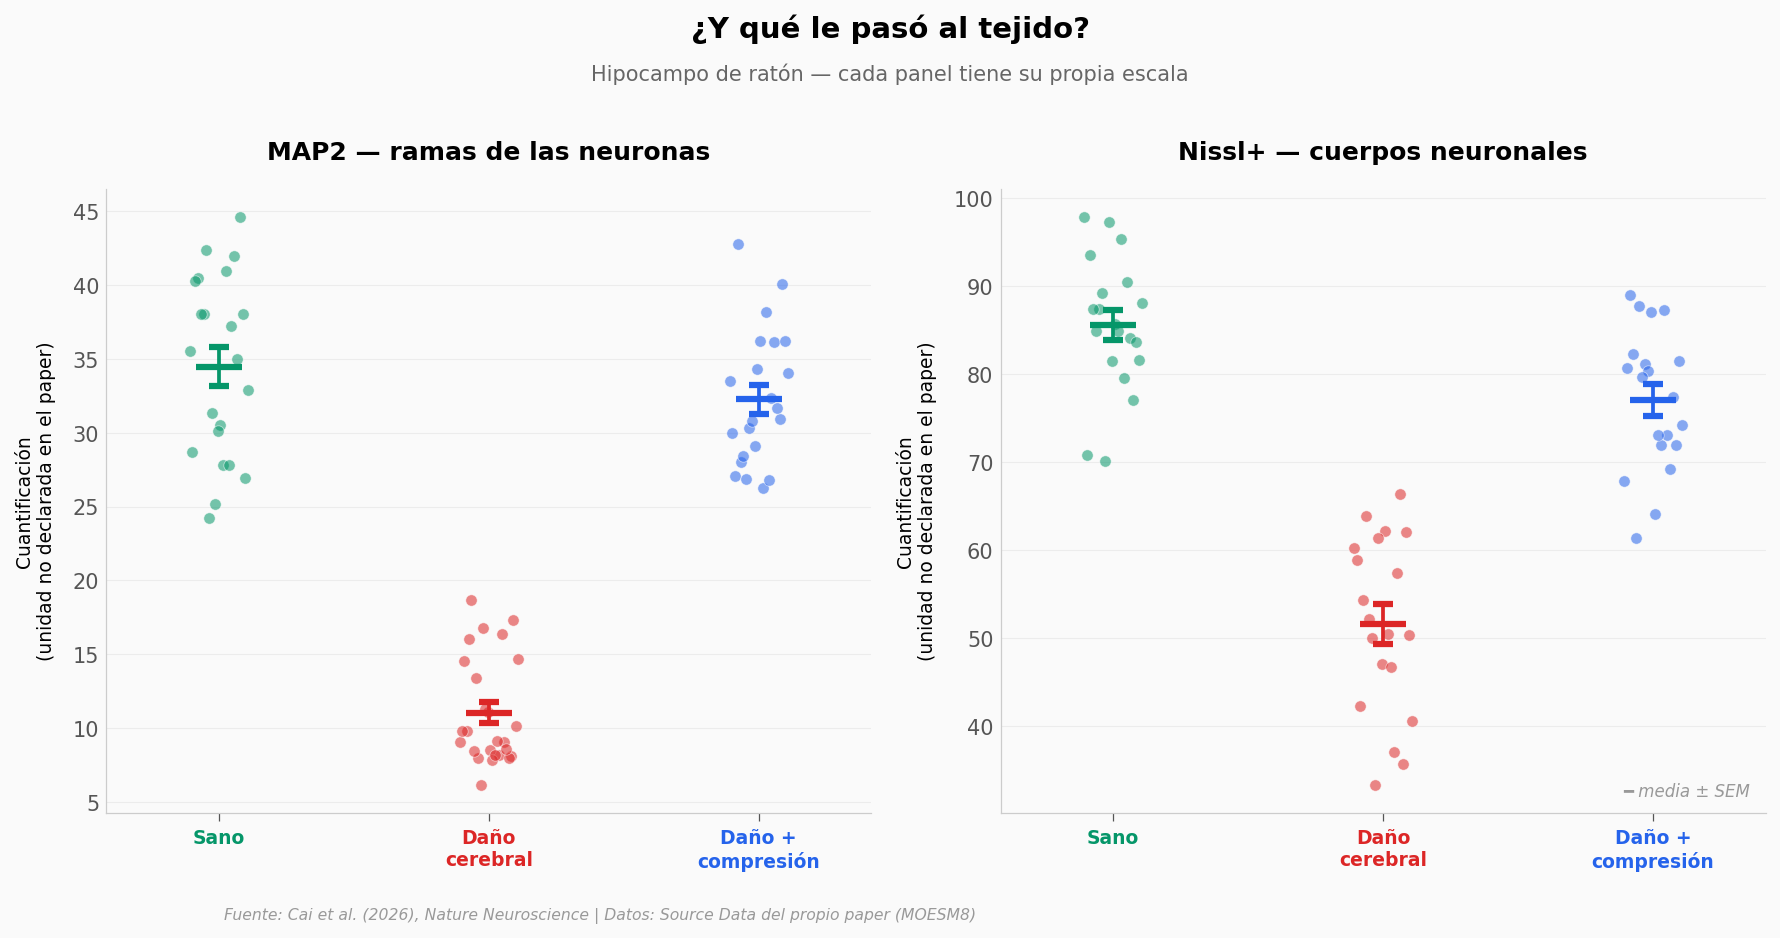

Tamaño de efecto (d de Cohen) de daño → daño + compresión:

  En el tejido
    MAP2  : 11,04 → 32,27  d = 5,20, p = 3.5e-09  (n = 26 vs 22)
    Nissl+: 51,62 → 77,06  d = 2,81, p = 1.4e-07  (n = 20 vs 20)

  En la conducta
    poste    : d = 1,94, p = 1.2e-08
    cuadrante: d = 1,38, p = 5.5e-05

El efecto medido en el tejido es mayor que el medido en la conducta. No es raro:
una diferencia histológica se mide en cortes muy controlados, mientras que un ratón
bajando de un poste añade ruido de motivación, de peso y de reloj. Son dos ventanas
distintas al mismo fenómeno, no dos versiones del mismo número.


In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿el efecto sobre el TEJIDO es tan grande como el efecto sobre la CONDUCTA?
#
# La Fig. 2 mide dos cosas en el hipocampo: MAP2 (una proteína de las ramificaciones de
# las neuronas) y el conteo de cuerpos neuronales teñidos con la técnica de Nissl.
# OJO: la leyenda del paper no declara en qué unidad están estas cuantificaciones, así
# que las usamos SOLO para comparar grupos entre sí, nunca como valor absoluto.

# MAP2 y Nissl+ son dos tinciones distintas y NINGUNA trae unidad declarada.
# Compartir eje Y insinuaria que 77 de Nissl es "mas" que 32 de MAP2, y eso no
# significa nada: van en paneles con escala propia. Solo se comparan grupos
# DENTRO de cada panel.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
np.random.seed(42)

medidas = [('map2_hipocampo', 'MAP2 — ramas de las neuronas', axes[0]),
           ('celulas_nissl_positivas', 'Nissl+ — cuerpos neuronales', axes[1])]

for metrica, titulo, ax in medidas:
    for i, (clave, _, color) in enumerate(GRUPOS):
        v = serie(hist, metrica=metrica, grupo=clave)
        n = len(v)
        x = np.linspace(posiciones[i] - 0.13, posiciones[i] + 0.13, n)
        np.random.shuffle(x)
        ax.scatter(x, v, color=color, s=30, alpha=0.55,
                   edgecolors='white', linewidths=0.4, zorder=5)
        sem = v.std(ddof=1) / np.sqrt(n)
        ax.errorbar(posiciones[i], v.mean(), yerr=sem, fmt='_', color=color,
                    markersize=22, markeredgewidth=3, capsize=5, capthick=1.5, zorder=6)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(['Sano', 'Daño\ncerebral', 'Daño +\ncompresión'],
                       fontsize=9, fontweight='bold')
    for tick, (_, _, color) in zip(ax.get_xticklabels(), GRUPOS):
        tick.set_color(color)
    ax.set_ylabel('Cuantificación\n(unidad no declarada en el paper)', fontsize=9)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
    ax.set_xlim(-0.5, 2.9)

axes[1].text(0.98, 0.02, '━ media ± SEM', transform=axes[1].transAxes,
             fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
plt.tight_layout()
fig.suptitle('¿Y qué le pasó al tejido?', fontsize=14, fontweight='bold', y=1.13)
fig.text(0.5, 1.045, 'Hipocampo de ratón — cada panel tiene su propia escala',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tejido_hipocampo.png', dpi=200, bbox_inches='tight')
plt.show()

print('Tamaño de efecto (d de Cohen) de daño → daño + compresión:\n')
print('  En el tejido')
for metrica, etiqueta in [('map2_hipocampo', 'MAP2  '),
                          ('celulas_nissl_positivas', 'Nissl+')]:
    a = serie(hist, metrica=metrica, grupo='TBI')
    b = serie(hist, metrica=metrica, grupo='TBI+LOAD')
    d, p = compara(a, b)
    print(f'    {etiqueta}: {esp(a.mean())} → {esp(b.mean())}  '
          f'd = {esp(d)}, p = {p:.1e}  (n = {len(a)} vs {len(b)})')

print('\n  En la conducta')
for df, metrica, etiqueta in [(pole, 'tiempo_total', 'poste    '),
                              (mwm, 'tiempo_cuadrante_diana', 'cuadrante')]:
    a = serie(df, metrica=metrica, momento=MOMENTO, grupo='TBI')
    b = serie(df, metrica=metrica, momento=MOMENTO, grupo='TBI+LOAD')
    d, p = compara(a, b)
    print(f'    {etiqueta}: d = {esp(d)}, p = {p:.1e}')

print('\nEl efecto medido en el tejido es mayor que el medido en la conducta. No es raro:')
print('una diferencia histológica se mide en cortes muy controlados, mientras que un ratón')
print('bajando de un poste añade ruido de motivación, de peso y de reloj. Son dos ventanas')
print('distintas al mismo fenómeno, no dos versiones del mismo número.')

---

## Fuentes

**Paper**: [Tibial bone compression promotes recovery after brain injury through osteocyte PIEZO1](https://doi.org/10.1038/s41593-026-02422-w)  
*Nature Neuroscience, 2026-09-21 · paywall*

**Source Data**: [Source Data for Figs. 1-7 and Extended Data Figs. 1-8 (MOESM8) — Tibial bone compression promotes recovery after brain injury through osteocyte PIEZO1](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41593-026-02422-w/MediaObjects/41593_2026_2422_MOESM8_ESM.xlsx)  
*Nature Neuroscience, 2026-09-21*

**Supplementary Material**: [Supplementary Table 2 — Complete statistical reporting (MOESM3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41593-026-02422-w/MediaObjects/41593_2026_2422_MOESM3_ESM.xlsx)  
*Nature Neuroscience, 2026-09-21*

*23 afirmaciones del notebook verificadas contra estas fuentes*

---

*Ciencia a Mordiscos — El Lab* · Notebook reproducible ·
[Repositorio](https://github.com/Ciencia-a-Mordiscos/lab)